In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_test'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_512'),
 PosixPath('/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_2')]

In [5]:
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

In [3]:
scenario_name = "ex_con_2025_full_wide_2"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

In [4]:
vars = ['psi_leaf_50_close', 'd_50_close','stem_hydraulic_capacitance', 'k_xylem_sat','huber_value',  'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0','jackson_root_beta',  'pore_0',  'root_area_index', 'wcont_sigma_deviation','g_bark', 'vmax25' , 'jmax25']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem' ,'g0','jackson_root_beta']

In [5]:
post_path

'/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/ex_con_2025_full_wide_2/post'

In [8]:
df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
df = df[df['RMSE_MAX'] < 1.1]
df_grp = df.groupby(['id'])[vars].mean()

In [9]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
5224,4,2280,1044,1800.0,1800,False,1.0,4.0,Weibull,35.262002,...,18.316056,18.504135,10.259223,10.722171,10.240719,10.139969,11.496482,0.967506,1.005609,4
5223,3,3447,1044,1800.0,1800,False,1.0,4.0,Weibull,35.603414,...,12.532379,16.692157,8.180596,8.560551,8.165030,8.096944,9.452842,0.967506,1.005609,3
5221,1,8082,1044,1800.0,1800,False,1.0,4.0,Weibull,27.315444,...,3.232286,3.464950,2.038737,2.229343,2.007528,1.973006,2.287901,0.967506,1.005609,1
5220,0,8892,1044,1800.0,1800,False,1.0,4.0,Weibull,35.360889,...,0.323231,0.385828,0.422360,0.430925,0.491204,0.378675,0.437098,0.967506,1.005609,0
5222,2,4106,1044,1800.0,1800,False,1.0,4.0,Weibull,28.329270,...,1.839349,1.968659,1.110124,1.252135,1.096934,1.037039,1.272223,0.967506,1.005609,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11545,0,8589,2309,1800.0,1800,False,1.0,4.0,Weibull,47.577287,...,0.318006,0.301547,0.406549,0.382473,0.491706,0.368890,0.406234,0.935997,1.099972,0
11546,1,8204,2309,1800.0,1800,False,1.0,4.0,Weibull,41.694152,...,3.176792,3.402893,1.966111,2.149261,1.936475,1.898090,2.214904,0.935997,1.099972,1
11548,3,9996,2309,1800.0,1800,False,1.0,4.0,Weibull,35.357920,...,3.363643,3.599389,2.076541,2.261616,2.045459,2.010650,2.337657,0.935997,1.099972,3
11547,2,83,2309,1800.0,1800,False,1.0,4.0,Weibull,39.700362,...,1.739962,1.841110,1.001794,1.137822,0.982262,0.925772,1.159162,0.935997,1.099972,2


In [10]:
df.loc[df['sid'] == 3,'sid']= 4
df.loc[df['sid'] == 2,'sid']= 3
df['sid']

5224     4
5223     4
5221     1
5220     0
5222     3
        ..
11545    0
11546    1
11548    4
11547    3
11549    4
Name: sid, Length: 2180, dtype: int64

In [11]:
dead_ids =[0,3,6,7]
dfs =df[df['sid'] == 0]
dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
dfs.to_csv(os.path.join(post_path, "Alive.csv"))
for i in range(1,5):
    dfs =df[df['sid'] == i]
    dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)
    dfs.to_csv(os.path.join(post_path, f"Dead{i}.csv"))

/tmp/ipykernel_235477/984454782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=['alive_mean'], inplace=True, ascending=True)
/tmp/ipykernel_235477/984454782.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs.sort_values(by=[f't{dead_ids[i - 1]}'], inplace=True, ascending=True)


In [12]:
for var in vars:
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(1,1,1)
    ax.hist(df_grp[var], alpha=1.0, bins = 20)
    ax.set_xlabel(var)
    plt.savefig(f"{post_path}/mean_hist_{var}.png")
    plt.close(fig)

In [13]:
dv = df[vars]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm=(dv-dv.mean())/dv.std()
df_norm['sid'] = df['sid']

/tmp/ipykernel_235477/3013431960.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])


In [14]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,vmax25,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
5224,4,2280,1044,1800.0,1800,False,1.0,4.0,Weibull,35.262002,...,18.316056,18.504135,10.259223,10.722171,10.240719,10.139969,11.496482,0.967506,1.005609,4
5223,3,3447,1044,1800.0,1800,False,1.0,4.0,Weibull,35.603414,...,12.532379,16.692157,8.180596,8.560551,8.165030,8.096944,9.452842,0.967506,1.005609,4
5221,1,8082,1044,1800.0,1800,False,1.0,4.0,Weibull,27.315444,...,3.232286,3.464950,2.038737,2.229343,2.007528,1.973006,2.287901,0.967506,1.005609,1
5220,0,8892,1044,1800.0,1800,False,1.0,4.0,Weibull,35.360889,...,0.323231,0.385828,0.422360,0.430925,0.491204,0.378675,0.437098,0.967506,1.005609,0
5222,2,4106,1044,1800.0,1800,False,1.0,4.0,Weibull,28.329270,...,1.839349,1.968659,1.110124,1.252135,1.096934,1.037039,1.272223,0.967506,1.005609,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11545,0,8589,2309,1800.0,1800,False,1.0,4.0,Weibull,47.577287,...,0.318006,0.301547,0.406549,0.382473,0.491706,0.368890,0.406234,0.935997,1.099972,0
11546,1,8204,2309,1800.0,1800,False,1.0,4.0,Weibull,41.694152,...,3.176792,3.402893,1.966111,2.149261,1.936475,1.898090,2.214904,0.935997,1.099972,1
11548,3,9996,2309,1800.0,1800,False,1.0,4.0,Weibull,35.357920,...,3.363643,3.599389,2.076541,2.261616,2.045459,2.010650,2.337657,0.935997,1.099972,4
11547,2,83,2309,1800.0,1800,False,1.0,4.0,Weibull,39.700362,...,1.739962,1.841110,1.001794,1.137822,0.982262,0.925772,1.159162,0.935997,1.099972,3


In [15]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,root_area_index,wcont_sigma_deviation,g_bark,vmax25,jmax25,sid
5224,-0.607167,0.160223,-0.353023,-0.983685,-0.374625,0.935277,-0.379760,1.102615,-0.716890,-0.323387,-0.932502,-1.323599,0.151699,-0.597450,-0.946745,-1.429861,-0.568086,-0.355450,4
5223,-0.506524,-0.429006,1.172812,-1.373259,-0.312226,0.772084,1.419442,2.192583,-0.625131,-0.988118,-1.510291,-0.438017,-0.384958,-1.304471,0.179671,-1.433010,-0.521966,-0.213868,4
5221,0.597953,0.134001,0.240352,-0.801239,-0.699144,0.900242,-1.584195,0.557393,-0.518704,-1.017581,0.094982,-1.270711,-0.081363,-1.409281,-0.026077,-1.428929,-1.641556,0.672930,1
5220,-1.400620,0.011087,-0.345092,-0.945607,-1.256930,0.848914,1.167649,2.608141,-0.498249,0.364517,0.204070,1.317800,2.033583,-1.357459,1.588985,-1.439637,-0.554728,0.597541,0
5222,-0.263862,-0.611923,1.020097,-0.765586,0.319380,0.737596,1.390822,0.565056,-0.888669,0.571892,-0.874765,0.623765,-0.838674,-0.972604,0.281123,-1.437322,-1.504602,-1.361296,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11545,-0.056291,1.408053,-1.330375,1.099138,-0.321510,-1.193537,-0.846380,0.011008,0.698120,1.013443,-0.993502,1.294925,2.591915,-0.744474,1.557319,-0.815755,1.095539,1.082511,0
11546,0.501571,1.806693,-0.414214,1.997971,0.814022,-1.471967,1.356438,0.032192,0.328470,0.528429,1.329249,-1.229339,-0.762005,-0.772010,-0.657505,-0.826152,0.300809,0.276715,1
11548,0.140996,1.073929,0.351276,1.502586,0.505190,-1.386694,0.546530,-0.761378,-0.083949,-0.523625,0.924026,-0.667366,0.108654,-0.964844,-1.129549,-0.833436,-0.555129,0.006818,4
11547,0.388424,1.660929,0.235681,2.149360,0.873302,-1.246666,-1.036554,-0.826056,0.620526,0.690218,-0.705693,0.894768,-0.540273,-0.194531,0.059262,-0.793952,0.031475,1.930135,3


ValueError: operands could not be broadcast together with shapes (324,) (162,) 

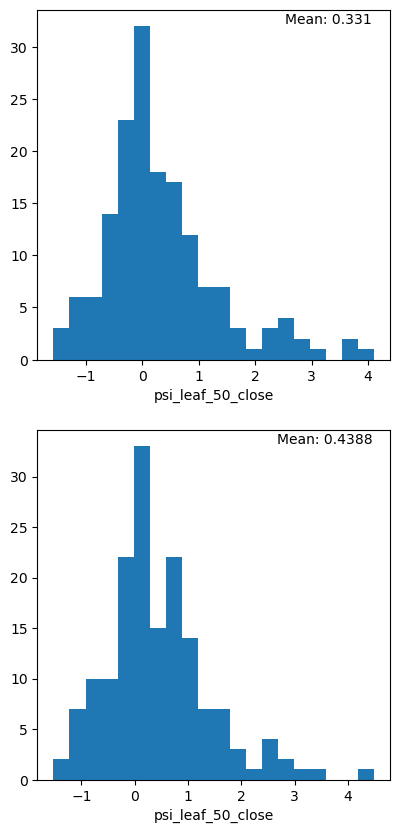

In [23]:
for var in vars:
   #if (var == 'id') | (var == 'sid'):
   #     continue        
    fig = plt.figure(figsize=(10,10))
    for sid in [1,3,4]:
        dfh = pd.DataFrame()
        dfh[var] = df_norm[df_norm['sid'] == sid][var].values - df_norm[df_norm['sid'] == 0][var].values
        ax = fig.add_subplot(2,2,sid)
        ax.hist(dfh[var], alpha=1.0, bins = 20)
        ax.set_xlabel(var)
        ax.text(0.95, 0.95, f"Mean: {np.round(dfh[var].mean(), 4)}",
        verticalalignment ='bottom',
        horizontalalignment ='right',
        transform = ax.transAxes)
    plt.savefig(f"{post_path}/sid_hist_{var}.png")
    plt.close(fig)